<a href="https://colab.research.google.com/github/nblashintaa/PBA-Brimo-SentimentAnalysis/blob/main/NAMA_NOTEBOOK.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# BRImo Review Sentiment Analysis
### Nabila Shinta Luthfia
### 5026231038

In [2]:
#Install library yang digunakan untuk scraping Google Play Store
!pip install google_play_scraper
!pip install textblob

#Import library yang digunakan
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

plt.style.use('seaborn-v0_8')
plt.rcParams["figure.figsize"] = (15,10)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00


In [15]:
# Mengambil 20000 review terbaru dari aplikasi BRImo di Google Play Store
# Menggunakan library google_play_scraper

from google_play_scraper import app, Sort, reviews

brimo_reviews, continuation_token = reviews(
    'id.co.bri.brimo',
    lang='id', # mengambil review bahasa Indonesia
    sort=Sort.NEWEST, # mengambil review terbaru
    count=20000 # mengambil 20000 review
)

In [16]:
# Data hasil scraping diubah menjadi pandas dataframe. Kemudian disimpan dalam file CSV untuk analisis selanjutnya
df_nhsrev = pd.DataFrame(np.array(brimo_reviews),columns=['content'])
df_nhsrev = df_nhsrev.join(pd.DataFrame(df_nhsrev.pop('content').tolist()))
df_nhsrev.to_csv("brimo_raw_reviews.csv", index=False) # menyimpan raw dataset
df_nhsrev.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,80048d20-63b3-47f8-bfee-01f6cfd5215a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,cepat ga ribet,5,0,None,2026-03-09 12:10:38,"Hai Sobat BRI, terima kasih atas ulasannya ☺️. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Dino",2026-03-09 12:49:11,None
1,59f13a6e-e46c-4d02-9ed5-26c1f22f2912,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Kenapa pendaftar awal investasi dplk dan brifine mengisi saldo melalui Brimo pribadi tidak dapak maksuk saldo ke brifine,sehingga saya lakukan top up 2 kali sukses namun saya cek ke brifine tidak ...",4,0,None,2026-03-09 12:07:18,"Hai Sobat BRI, mohon maaf atas kendala yang dialami. Untuk tindak lanjut, silakan kirimkan detail kendala melalui email callbri@bri.co.id. Tks~Dino",2026-03-09 12:45:53,None
2,0254af9a-1fd3-45e7-a88b-17c04f0a9eed,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,tiap buka bri mo selalu muncul layar putih tolong penjelasannha makasih,2,0,None,2026-03-09 12:06:14,"Hai Sobat BRI, mohon maaf atas kendala yang dialami. Untuk tindak lanjut, silakan kirimkan detail kendala melalui email callbri@bri.co.id. Tks~Dino",2026-03-09 12:54:05,None
3,b172894f-97d8-4c37-ba16-d503fb974170,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,bagus,5,0,None,2026-03-09 12:04:40,"Hai Sobat BRI, terima kasih atas ulasannya ☺️. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Dino",2026-03-09 12:47:13,None
4,aef83e0e-7cb2-45dd-ad3d-1b28599d8ee5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mantap,5,0,2.94.0,2026-03-09 12:02:26,"Hai Sobat BRI, terima kasih atas ulasannya ☺️. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Dino",2026-03-09 12:46:36,2.94.0


In [25]:
import re

def clean_text(text):

    text = text.lower()                     # mengubah semua huruf menjadi lowercase
    text = re.sub(r'http\S+', '', text)     # menghapus URL
    text = re.sub(r'\d+', '', text)         # menghapus angka
    text = re.sub(r'[^\w\s]', '', text)     # menghapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()# menghapus spasi berlebih

    return text

In [26]:
# Membuat kolom baru berisi review yang sudah dibersihkan
df_nhsrev['clean_review'] = df_nhsrev['content'].apply(clean_text)

df_nhsrev[['content','clean_review']].head()

,content,clean_review
0,cepat ga ribet,cepat ga ribet
1,"Kenapa pendaftar awal investasi dplk dan brifine mengisi saldo melalui Brimo pribadi tidak dapak maksuk saldo ke brifine,sehingga saya lakukan top up 2 kali sukses namun saya cek ke brifine tidak ...",kenapa pendaftar awal investasi dplk dan brifine mengisi saldo melalui brimo pribadi tidak dapak maksuk saldo ke brifinesehingga saya lakukan top up kali sukses namun saya cek ke brifine tidak ada...
2,tiap buka bri mo selalu muncul layar putih tolong penjelasannha makasih,tiap buka bri mo selalu muncul layar putih tolong penjelasannha makasih
3,bagus,bagus
4,mantap,mantap


In [17]:
print(df_nhsrev.reviewCreatedVersion.unique())
print(df_nhsrev.reviewCreatedVersion.nunique())

[None '2.94.0' '2.76.0' '2.93.0' '2.87.1' '2.88.1' '2.92.0' '2.75.0'
 '2.92.1' '2.82.0' '2.57.0' '2.89.0' '2.52.0' '2.88.0' '2.45.1' '2.62.0'
 '2.32.0' '2.91.0' '2.27.0' '2.90.0' '2.20.0' '2.53.0' '2.38.0' '2.83.0'
 '2.22.0' '2.78.0' '2.59.0' '2.71.1' '2.40.0' '2.61.0' '2.56.0' '2.74.0'
 '2.85.0' '1.8.0' '2.46.0' '2.42.0' '2.34.0' '2.70.0' '2.48.0' '2.81.0'
 '2.29.0' '2.11.0' '2.23.1' '2.72.0' '2.26.0' '2.58.0' '1.4.1' '2.44.0'
 '2.21.0' '2.39.0' '2.77.0' '2.64.0' '2.80.0' '2.86.0' '1.7.0' '2.77.1'
 '2.18.0' '2.31.0' '2.49.0' '2.51.0' '2.43.1' '2.7.0' '2.69.0' '2.25.0'
 '2.55.0' '2.68.0' '2.37.0' '2.20.1' '2.47.0' '2.14.0' '2.60.0' '2.57.1'
 '2.35.0' '2.1.0' '2.63.0' '2.13.0' '2.65.0' '2.67.0' '2.41.0' '2.84.0'
 '2.3.2' '2.71.0' '2.73.0' '2.43.0' '2.17.0' '2.67.1']
85


In [27]:
# Menyimpan dataset setelah proses cleaning
df_nhsrev.to_csv("brimo_clean_reviews.csv", index=False)

In [28]:
# Menampilkan kolom yang relevan untuk analisis review aplikasi
df_nhsrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,cepat ga ribet,5,0,None,2026-03-09 12:10:38,"Hai Sobat BRI, terima kasih atas ulasannya ☺️. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Dino",2026-03-09 12:49:11
1,"Kenapa pendaftar awal investasi dplk dan brifine mengisi saldo melalui Brimo pribadi tidak dapak maksuk saldo ke brifine,sehingga saya lakukan top up 2 kali sukses namun saya cek ke brifine tidak ...",4,0,None,2026-03-09 12:07:18,"Hai Sobat BRI, mohon maaf atas kendala yang dialami. Untuk tindak lanjut, silakan kirimkan detail kendala melalui email callbri@bri.co.id. Tks~Dino",2026-03-09 12:45:53
2,tiap buka bri mo selalu muncul layar putih tolong penjelasannha makasih,2,0,None,2026-03-09 12:06:14,"Hai Sobat BRI, mohon maaf atas kendala yang dialami. Untuk tindak lanjut, silakan kirimkan detail kendala melalui email callbri@bri.co.id. Tks~Dino",2026-03-09 12:54:05
3,bagus,5,0,None,2026-03-09 12:04:40,"Hai Sobat BRI, terima kasih atas ulasannya ☺️. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Dino",2026-03-09 12:47:13
4,mantap,5,0,2.94.0,2026-03-09 12:02:26,"Hai Sobat BRI, terima kasih atas ulasannya ☺️. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Dino",2026-03-09 12:46:36
...,...,...,...,...,...,...,...
19995,mantep,5,0,None,2025-12-30 08:58:08,"Hai Sobat BRI, terima kasih atas ulasannya 😊. Semoga aplikasi BRImo semakin mempermudah transaksi Sobat BRI. Tks~Hiro",2025-12-30 09:12:36
19996,top,5,0,2.92.0,2025-12-30 08:52:53,"Hai Sobat BRI, terima kasih atas ulasannya 😊. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Arin",2025-12-30 09:08:50
19997,"Aplikasi busuk, akhir akhir ni sering eror, eror ngk dibaik-baikin layar jadi putih lama, menu login ngk muncul-muncul.",1,0,2.92.0,2025-12-30 08:52:16,"Hai Sobat BRI, mohon maaf atas kendala yang dialami. Untuk tindak lanjutnya silakan kirimkan detail kendala melalui email callbri@bri.co.id. Tks~Oman",2025-12-30 09:11:44
19998,bagus,4,0,None,2025-12-30 08:51:55,"Hai Sobat BRI, terima kasih atas ulasannya 😊. Semoga aplikasi BRImo semakin mempermudah aktivitas perbankan Sobat BRI. Tks~Arin",2025-12-30 09:13:15


In [29]:
# Library emoji digunakan untuk memproses karakter emoji dalam teks review
!pip install emoji

# Library tambahan untuk text preprocessing dan Natural Language Processing (NLP)
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

In [30]:
# Menghitung nilai sentiment dari setiap review menggunakan TextBlob
# Polarity menunjukkan tingkat positif/negatif
# Subjectivity menunjukkan tingkat subjektif atau objektif
# https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
df_nhsrev['sentiment_polarity'] = df_nhsrev['content'].apply(lambda x: TextBlob(str(x)).polarity)
df_nhsrev['sentiment_subjective'] = df_nhsrev['content'].apply(lambda x: TextBlob(str(x)).subjectivity)

In [31]:
# Menyimpan dataset setelah sentiment analysis
df_nhsrev.to_csv("brimo_sentiment_reviews.csv", index=False)

In [32]:
# Menampilkan isi review beserta nilai sentiment yang dihasilkan
df_nhsrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,cepat ga ribet,5,0.0,0.0
1,"Kenapa pendaftar awal investasi dplk dan brifine mengisi saldo melalui Brimo pribadi tidak dapak maksuk saldo ke brifine,sehingga saya lakukan top up 2 kali sukses namun saya cek ke brifine tidak ...",4,0.5,0.5
2,tiap buka bri mo selalu muncul layar putih tolong penjelasannha makasih,2,0.0,0.0
3,bagus,5,0.0,0.0
4,mantap,5,0.0,0.0
...,...,...,...,...
19995,mantep,5,0.0,0.0
19996,top,5,0.5,0.5
19997,"Aplikasi busuk, akhir akhir ni sering eror, eror ngk dibaik-baikin layar jadi putih lama, menu login ngk muncul-muncul.",1,0.0,0.0
19998,bagus,4,0.0,0.0


In [33]:
# Menghitung jumlah review berdasarkan rating yang diberikan pengguna
df_nhsrev['score'].value_counts()

,count
score,
5,14070
1,3032
4,1273
3,842
2,783


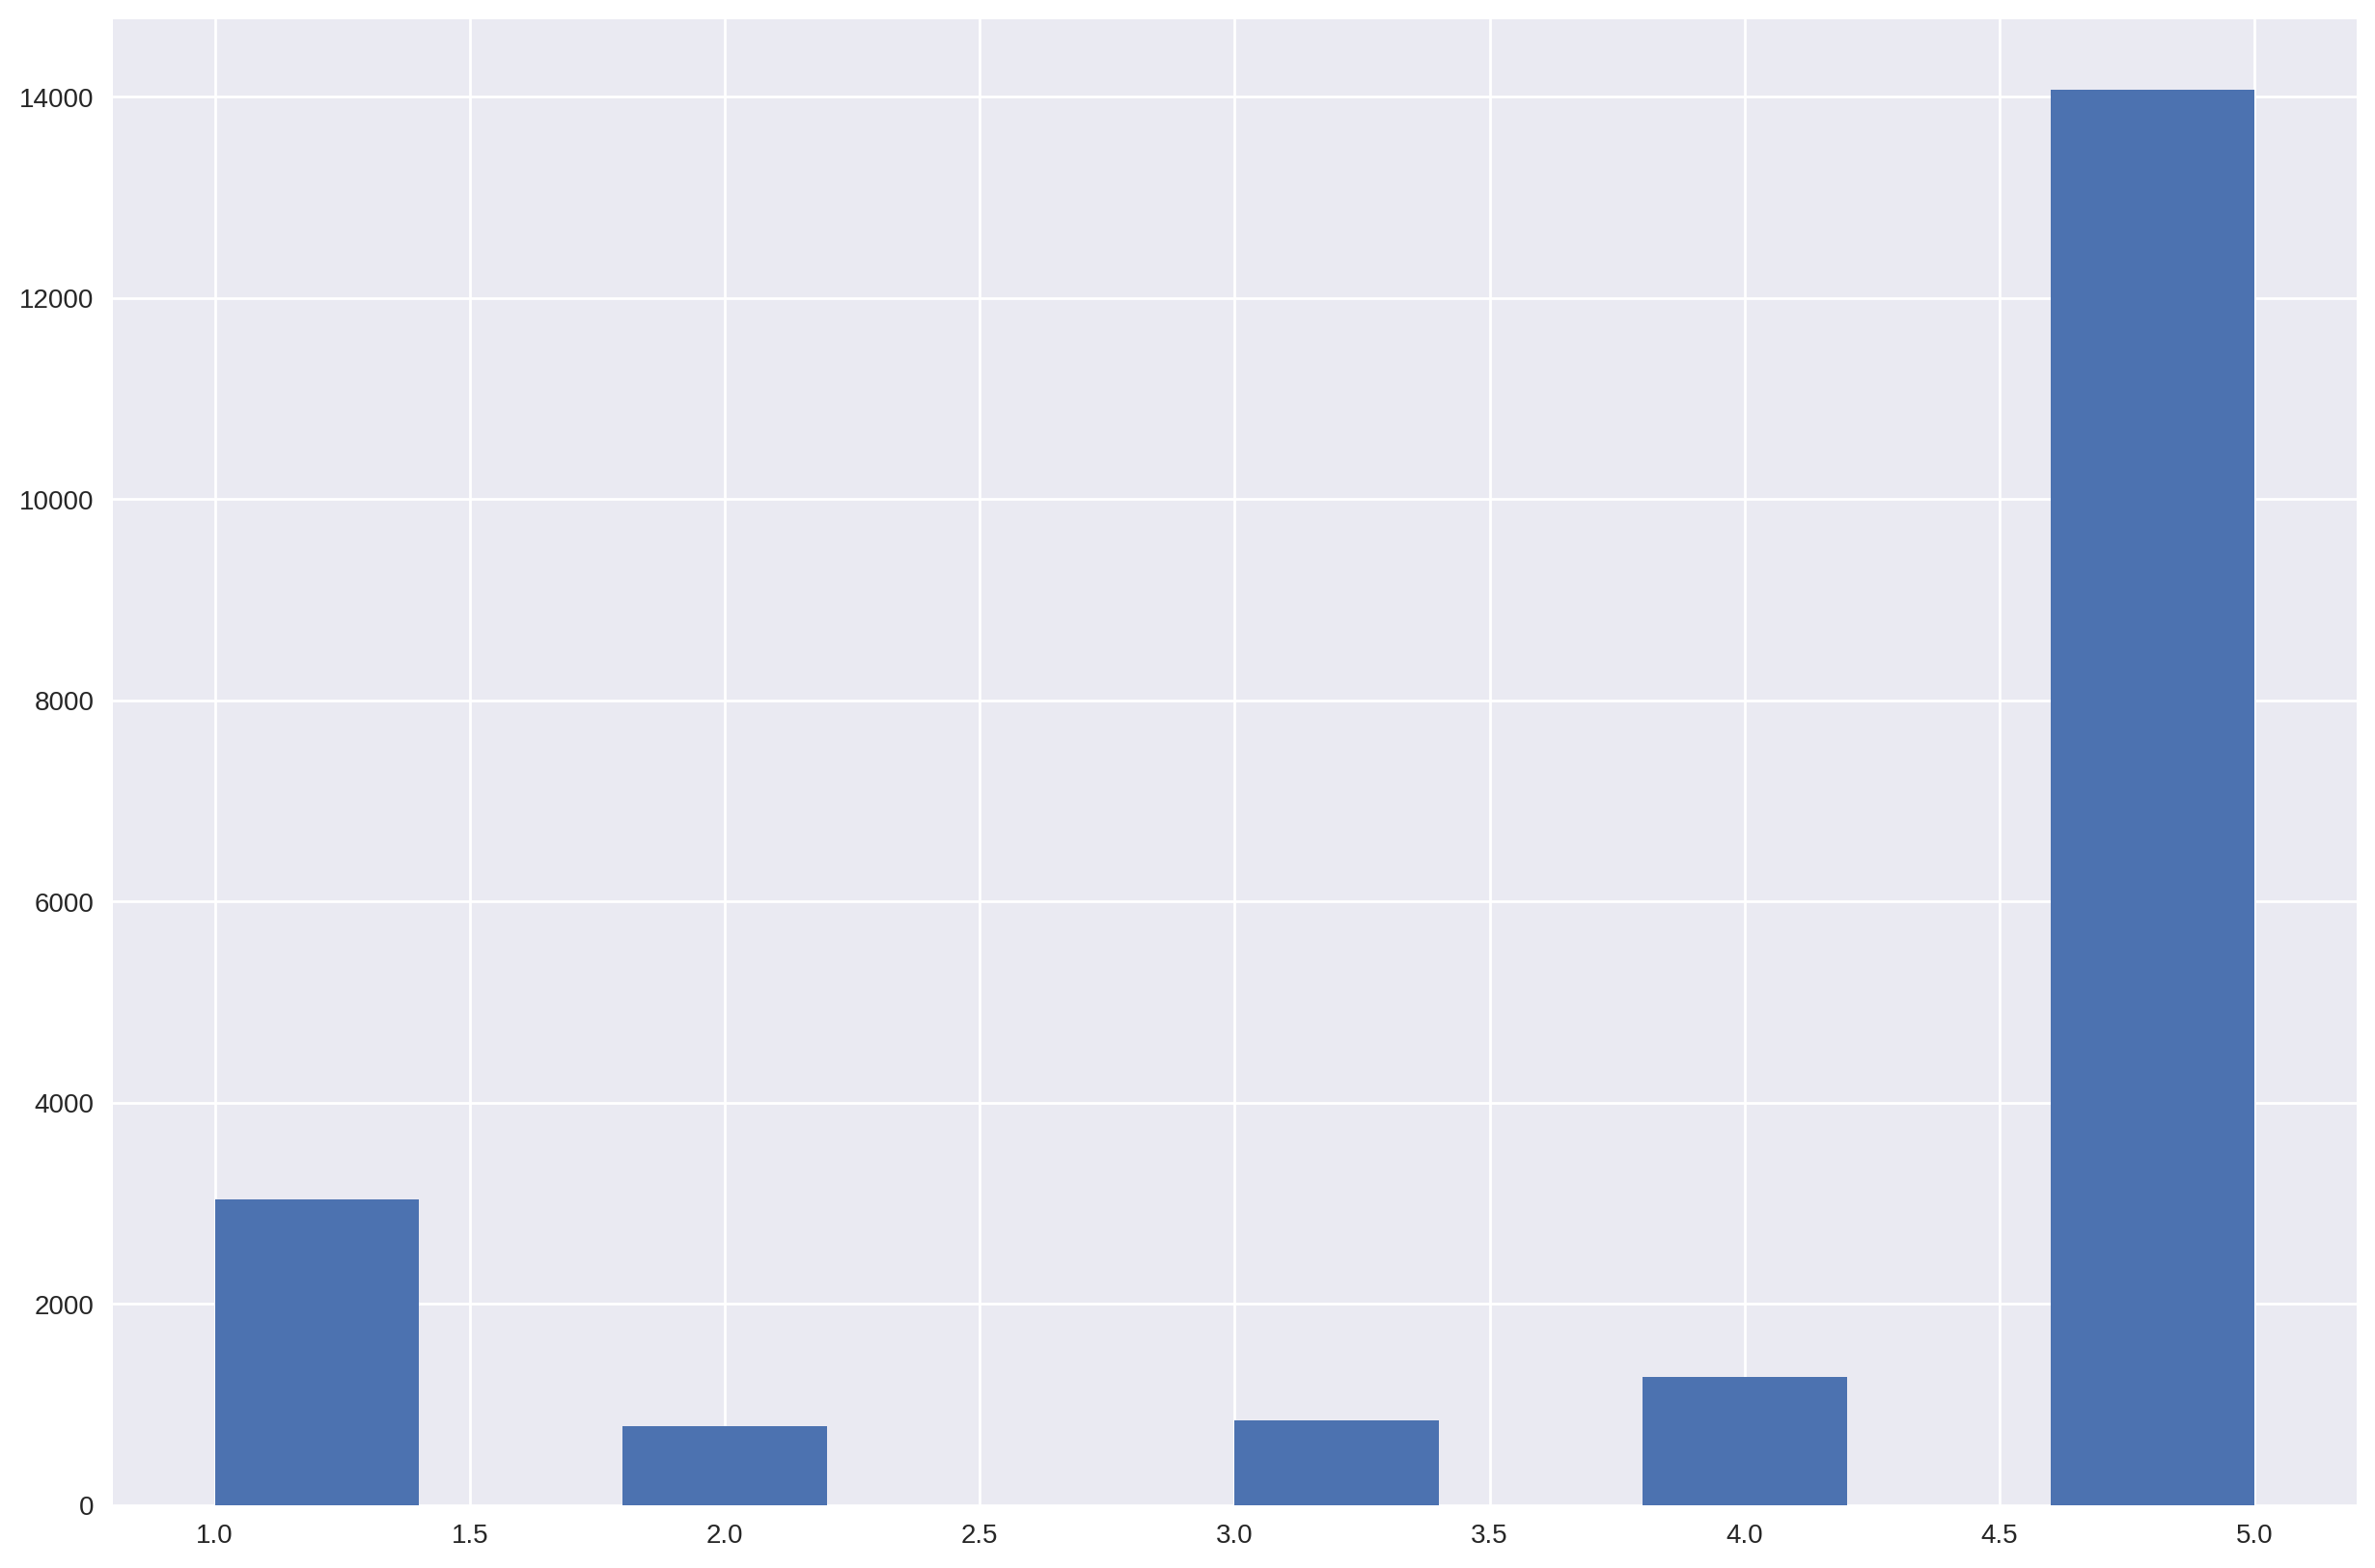

In [34]:
# Membuat grafik distribusi rating pengguna terhadap aplikasi BRImo
plt.hist(df_nhsrev['score'])
plt.show()